# 03 — Residual Analysis and Safety Metrics

Goal: move beyond MAE/RMSE and study **dangerous overestimation**.

Residual definition:

`residual = y_true - y_pred`

- Positive residual: model underestimates RUL → usually safer.
- Negative residual: model overestimates RUL → riskier because maintenance may be delayed.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import DEFAULT_RUL_CAP, RANDOM_STATE
from src.data.loading import load_train, sensor_columns
from src.features.build_features import add_rul_target, train_val_split_by_unit, prepare_xy
from src.models.train_baselines import fit_models, predict_models
from src.evaluation.metrics import residuals, make_safety_table, sweep_risk_loss, catastrophic_risk_index
from src.visualization.plots import plot_residuals, plot_low_rul_hist


In [3]:
df = load_train(DATA_DIR, "FD001")
df = add_rul_target(df, cap=DEFAULT_RUL_CAP)
train_df, val_df = train_val_split_by_unit(df, random_state=RANDOM_STATE)
features = sensor_columns(df)
X_train, y_train, X_val, y_val = prepare_xy(train_df, val_df, features)

fitted_models = fit_models(X_train, y_train, random_state=RANDOM_STATE)
predictions = predict_models(fitted_models, X_val)


## Residual plots

Look especially at the low-RUL region. Overestimating near failure is more dangerous than overestimating early in life.


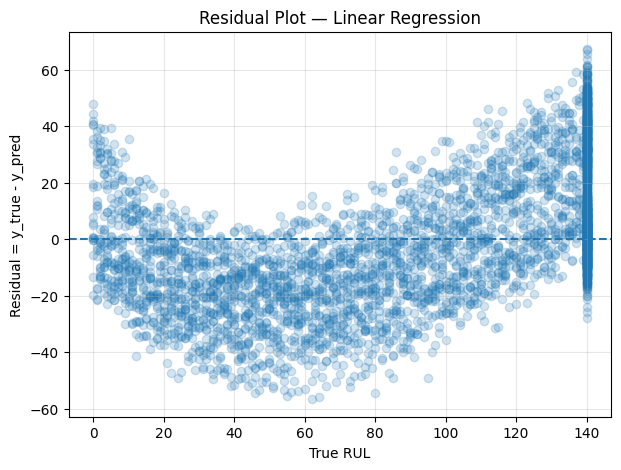

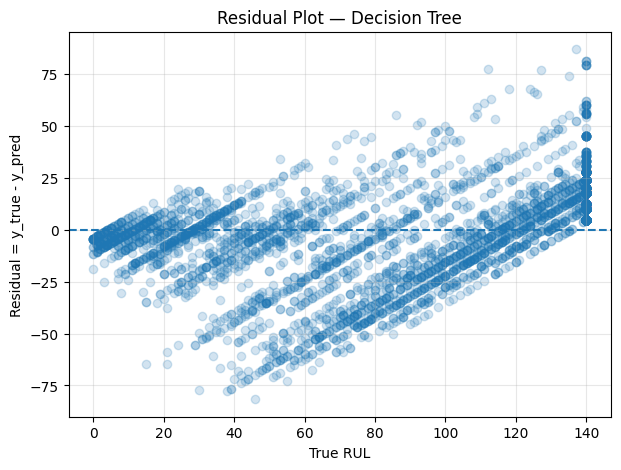

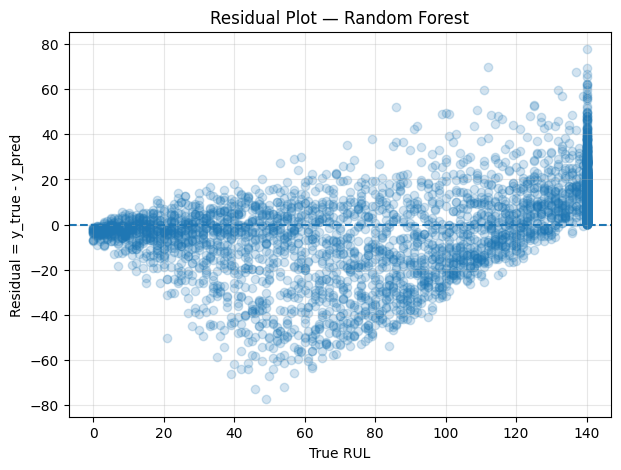

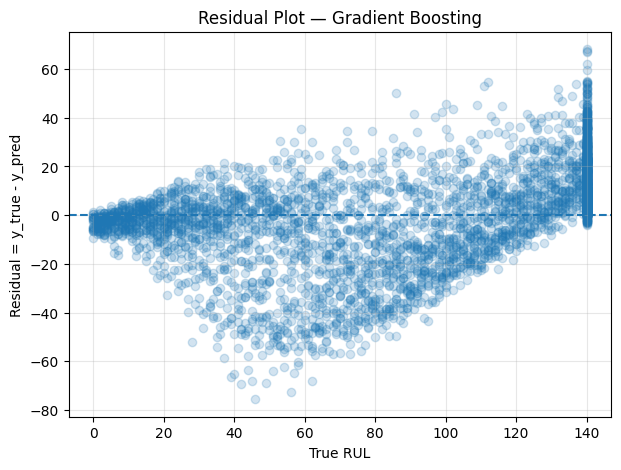

In [4]:
for model_name, y_pred in predictions.items():
    res = residuals(y_val, y_pred)
    plot_residuals(y_val, res, title=f"Residual Plot — {model_name}")
    plt.show()


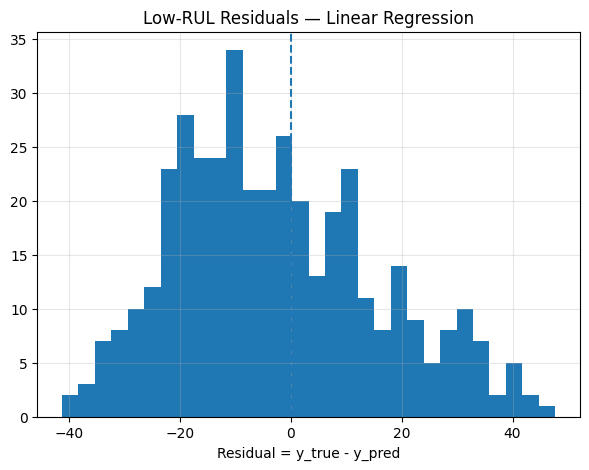

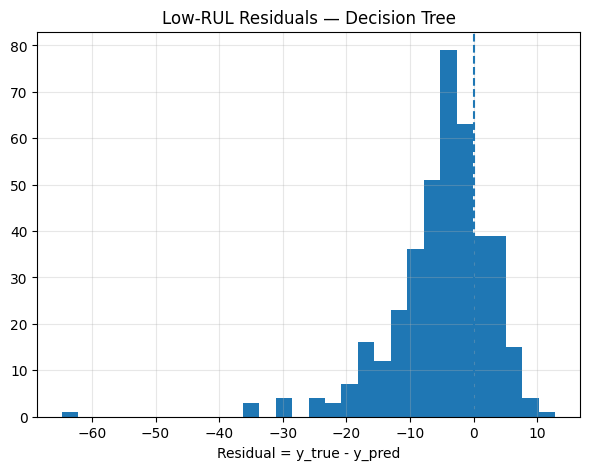

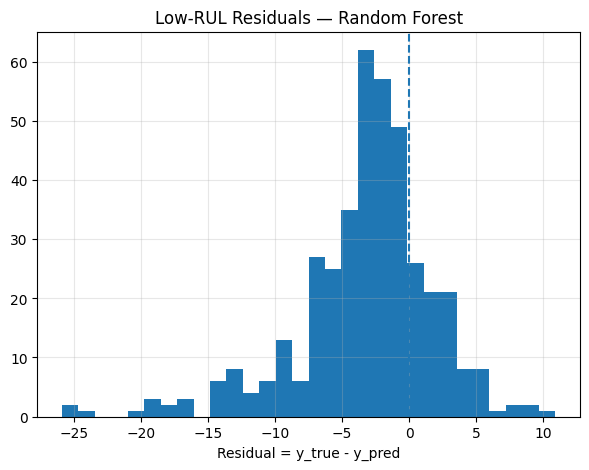

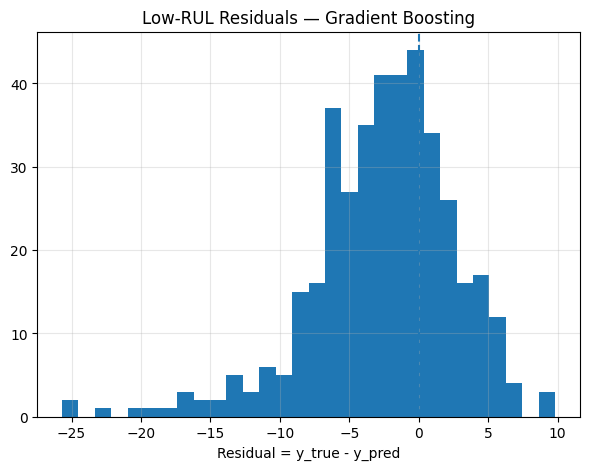

In [5]:
low_rul_threshold = 20
low_rul_mask = y_val < low_rul_threshold

for model_name, y_pred in predictions.items():
    res = residuals(y_val, y_pred)
    plot_low_rul_hist(res[low_rul_mask], title=f"Low-RUL Residuals — {model_name}")
    plt.show()


## Safety-MAE and dangerous overestimation

Safety-MAE weights overestimation more heavily. This matches your project idea: **not every error has equal cost**.


In [6]:
safety_df = make_safety_table(y_val, predictions, threshold=20)
safety_df


,Model,MAE,Safety_MAE,Dangerous_Count_RUL_LT_20,Avg_Overestimate_RUL_LT_20
0,Gradient Boosting,15.151342,22.608727,281,4.890702
1,Random Forest,15.233042,22.708700,315,4.876889
2,Decision Tree,17.418023,26.254659,302,7.792943
3,Linear Regression,18.824860,28.258486,239,15.108070


## Risk-loss sensitivity

We sweep λ and γ for an exponential asymmetric risk loss.

- λ controls how strongly overestimation is penalized.
- γ controls how much the penalty concentrates near very low RUL.


In [7]:
risk_grid = sweep_risk_loss(
    y_val,
    predictions,
    lambda_values=[1, 2, 3, 5],
    gamma_values=[0.01, 0.05, 0.1],
)
risk_grid.head(20)


,lambda,gamma,Model,Risk_Loss
0,1,0.01,Gradient Boosting,11.668667
1,1,0.01,Random Forest,11.776706
2,1,0.01,Decision Tree,13.415816
3,1,0.01,Linear Regression,14.786012
4,1,0.05,Gradient Boosting,8.338360
5,1,0.05,Random Forest,8.435334
6,1,0.05,Decision Tree,9.474110
7,1,0.05,Linear Regression,10.615308
8,1,0.10,Gradient Boosting,7.904421
9,1,0.10,Random Forest,7.980704


In [8]:
cri_rows = []
for model_name, y_pred in predictions.items():
    cri_rows.append({
        "Model": model_name,
        "CRI_RUL_lt_5": catastrophic_risk_index(y_val, y_pred, threshold=5),
    })
cri_df = pd.DataFrame(cri_rows).sort_values("CRI_RUL_lt_5")
cri_df


,Model,CRI_RUL_lt_5
2,Random Forest,3.206500
3,Gradient Boosting,3.375692
0,Linear Regression,4.319209
1,Decision Tree,5.808852


In [9]:
safety_df.to_csv(PROCESSED_DIR / "fd001_safety_metrics.csv", index=False)
risk_grid.to_csv(PROCESSED_DIR / "fd001_risk_loss_sensitivity.csv", index=False)
cri_df.to_csv(PROCESSED_DIR / "fd001_catastrophic_risk_index.csv", index=False)
print("Saved safety analysis tables")


Saved safety analysis tables
